In [1]:
import pandas as pd

CSV_PATH = r"C:\Users\User\Desktop\ml health\ML-assessment\diabetic_data.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset loaded! Shape:", df.shape)
df.head()


Dataset loaded! Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Fill missing values
df['race'].fillna('Unknown', inplace=True)
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

# Convert target to binary
df['readmitted'] = df['readmitted'].apply(lambda x: 0 if x=='NO' else 1)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


C:\Users\User\AppData\Local\Temp\ipykernel_14464\2756024364.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_14464\2756024364.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Your dataset path
CSV_PATH = r"C:\Users\User\Desktop\ml health\ML-assessment\diabetic_data.csv"

# Load data
df = pd.read_csv(CSV_PATH)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], "...")  # preview first few column names
df.head()


✅ Dataset loaded successfully!
Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital'] ...


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

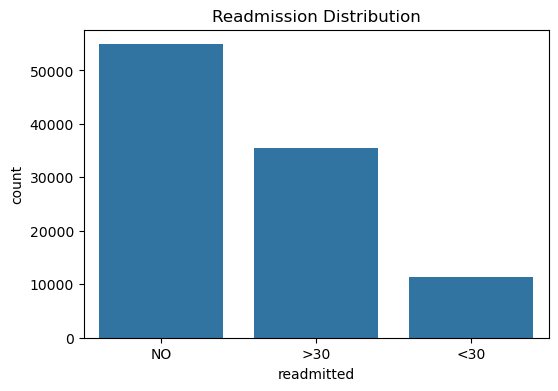

In [4]:
# Basic info
df.info()

# Check missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Basic statistics
df.describe(include='all')

# Check target distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title('Readmission Distribution')
plt.show()


In [5]:
# Drop columns with too many missing values or irrelevant info
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Fill missing or unknown values
df['race'].fillna('Unknown', inplace=True)
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

# Convert target to binary (if 'NO', '>30', '<30')
df['readmitted'] = df['readmitted'].apply(lambda x: 0 if x=='NO' else 1)


In [6]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target if it exists in the list
if 'readmitted' in cat_cols:
    cat_cols.remove('readmitted')

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,3,0,0,1,6,25,1,1,0,38,...,0,1,1,0,0,0,0,1,0,0
1,3,0,1,1,1,1,7,3,0,0,...,0,3,1,0,0,0,0,0,1,1
2,1,0,2,1,1,1,7,2,0,0,...,0,1,1,0,0,0,0,1,1,0
3,3,1,3,1,1,1,7,2,0,0,...,0,3,1,0,0,0,0,0,1,0
4,3,1,4,1,1,1,7,1,0,0,...,0,2,1,0,0,0,0,0,1,0


In [7]:
from sklearn.model_selection import train_test_split

# Features & target
X = df.drop('readmitted', axis=1)
y = df['readmitted']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (81412, 47)
Testing shape: (20354, 47)


Accuracy: 0.6390881399233566

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.74      0.69     10973
           1       0.63      0.52      0.57      9381

    accuracy                           0.64     20354
   macro avg       0.64      0.63      0.63     20354
weighted avg       0.64      0.64      0.63     20354



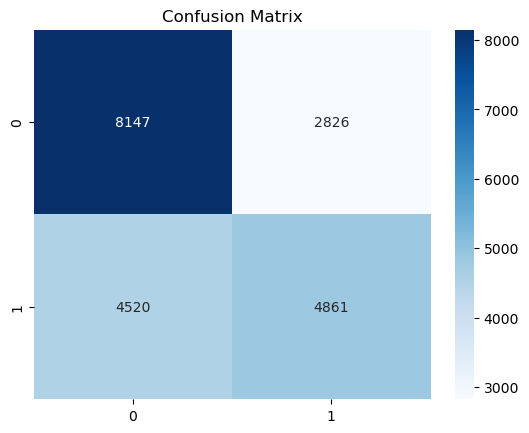

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


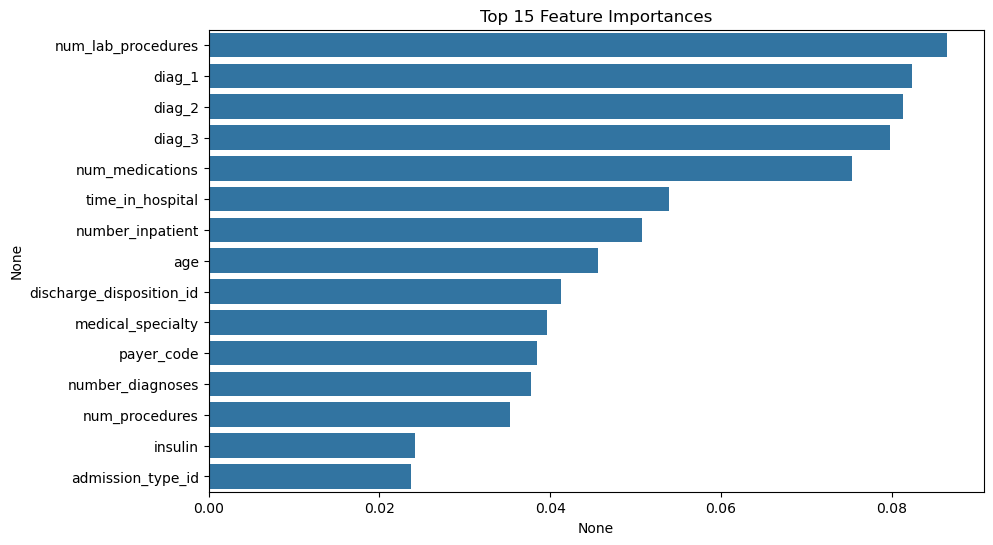

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:15], y=importances.index[:15])
plt.title("Top 15 Feature Importances")
plt.show()


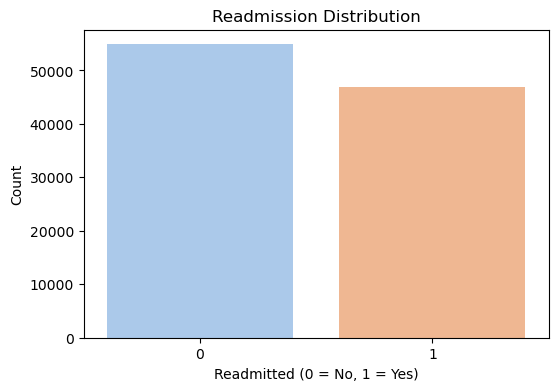

In [ ]:
# Readmission distribution
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df, palette='pastel')
plt.title("Readmission Distribution")g
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


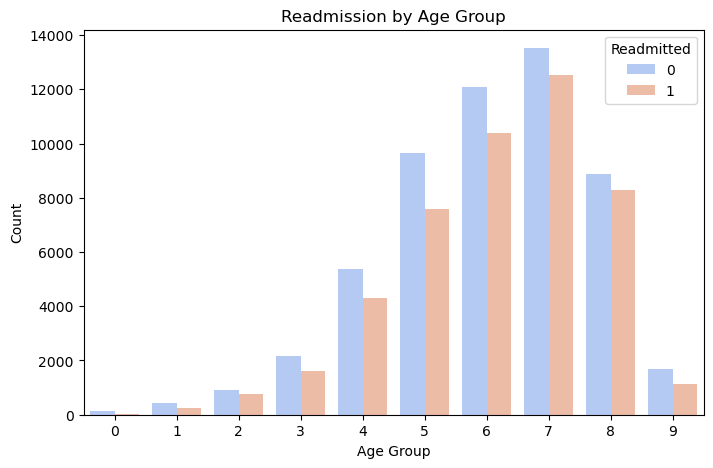

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='age', hue='readmitted', data=df, palette='coolwarm')
plt.title("Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title='Readmitted')
plt.show()


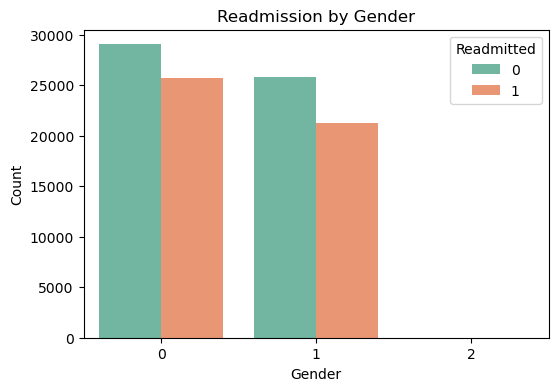

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='readmitted', data=df, palette='Set2')
plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='Readmitted')
plt.show()


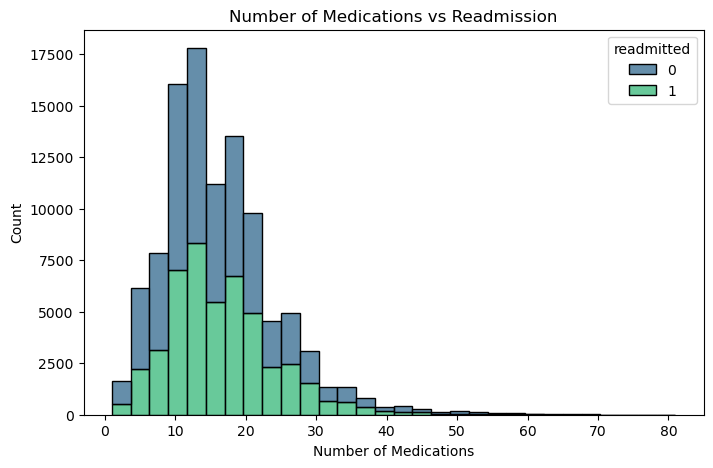

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='num_medications', hue='readmitted', multiple='stack', bins=30, palette='viridis')
plt.title("Number of Medications vs Readmission")
plt.xlabel("Number of Medications")
plt.ylabel("Count")
plt.show()


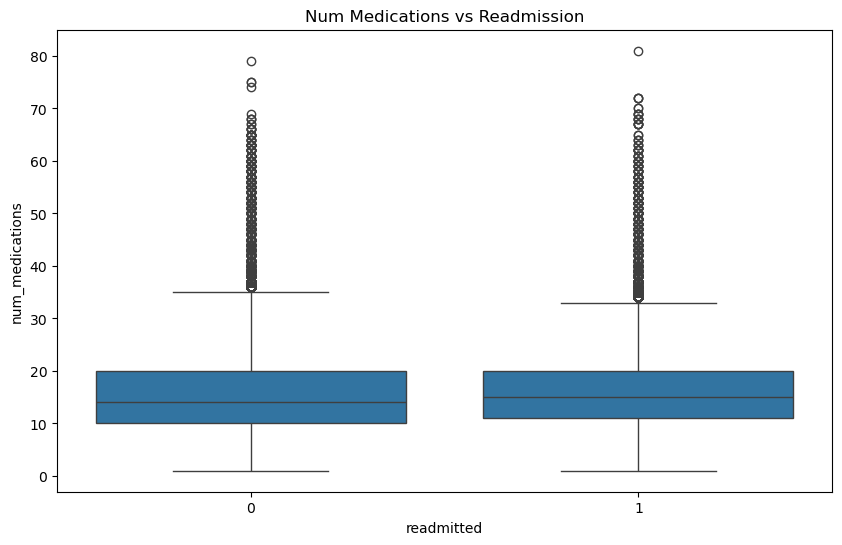

In [14]:
# Use the Random Forest feature importances
top_features = importances[:10].index
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='readmitted', y='num_medications')
plt.title("Num Medications vs Readmission")
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import pandas as pd


# Sort by 'time_in_hospital' to simulate chronological order
df_sorted = df.sort_values(by='time_in_hospital')

X = df_sorted.drop('readmitted', axis=1)
y = df_sorted['readmitted']

# Chronological train-test split
split_index = int(0.8 * len(df_sorted))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {roc}")
    print(classification_report(y_test, y_pred))
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": roc})


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False)
print("\n✅ Model Comparison:")
display(results_df)


Training shape: (81412, 47)
Testing shape: (20354, 47)

Training Random Forest...
Accuracy: 0.6194 | F1-Score: 0.6038 | ROC-AUC: 0.6737092438276433
              precision    recall  f1-score   support

           0       0.62      0.65      0.63     10310
           1       0.62      0.59      0.60     10044

    accuracy                           0.62     20354
   macro avg       0.62      0.62      0.62     20354
weighted avg       0.62      0.62      0.62     20354


Training XGBoost...
Accuracy: 0.6262 | F1-Score: 0.6348 | ROC-AUC: 0.6807172978178266
              precision    recall  f1-score   support

           0       0.64      0.59      0.62     10310
           1       0.61      0.66      0.63     10044

    accuracy                           0.63     20354
   macro avg       0.63      0.63      0.63     20354
weighted avg       0.63      0.63      0.63     20354


✅ Model Comparison:


,Model,Accuracy,F1-Score,ROC-AUC
1,XGBoost,0.626167,0.634832,0.680717
0,Random Forest,0.619387,0.603795,0.673709


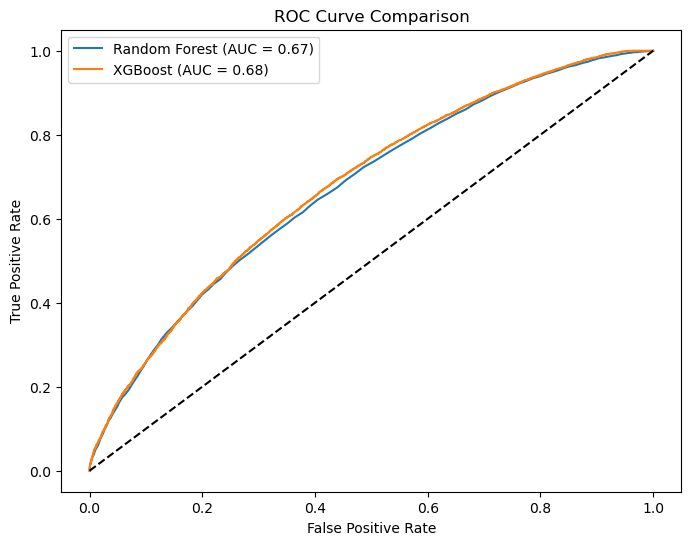

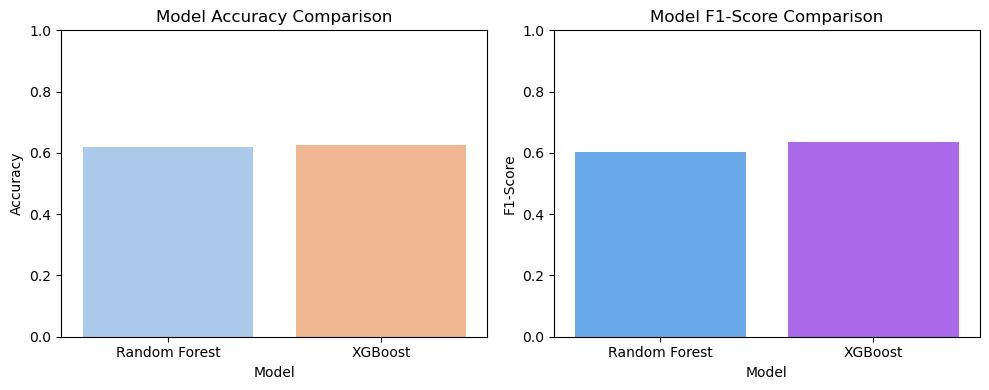

In [17]:
from sklearn.metrics import roc_curve, auc, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Models (only Random Forest and XGBoost)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train & Evaluate
results = []
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": roc_auc})
    
    # Plot ROC curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Finalize ROC Curve
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Convert results to DataFrame for bar charts
results_df = pd.DataFrame(results)

# ------------------------- Accuracy & F1-score Bar Charts -------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='pastel')
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

# F1-Score
plt.subplot(1,2,2)
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='cool')
plt.title("Model F1-Score Comparison")
plt.ylim(0,1)

plt.tight_layout()
plt.show()
